This notebook calcuates the MWs, and plots their distribution, to be used as a proxy for the total number of bonds a molecule can form. 

In [1]:
from pathlib import Path
import os
from functools import lru_cache
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer

from rdkit import Chem
from rdkit.Chem import Descriptors

from prob.interactions.interaction_data import load_ident_activity_mapping
from prob.prob_plots import plot_dist_with_log
from prob.paths_and_io import get_project_root, get_data_dir

In [2]:
mapping = load_ident_activity_mapping()
mapping.head(2)

,ident_processed,smiles,y_processed,ident,compound_structures.canonical_smiles,activities.standard_value,activity_id,similar.klifs_structure_id
0,0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,5.148742,0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,5.148742,32335,5326
1,17,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,6.000000,17,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,6.000000,40693,5326


To check if it suffies to only store ident

In [3]:
# Rows where two columns disagree
for col_a, col_b in [("ident", "ident_processed"), ("y_processed", "activities.standard_value"), ("smiles", "compound_structures.canonical_smiles")]:
    # Treat NaN == NaN as agreement; only keep real disagreements
    disagree_rows = mapping[mapping[col_a].ne(mapping[col_b]) & ~(mapping[col_a].isna() & mapping[col_b].isna())]
    # print(f"Rows where {col_a} and {col_b} disagree:\n{disagree_rows[col_a]}, {disagree_rows[col_b]}\n")
    print(f"Number of rows where {col_a} and {col_b} disagree: {len(disagree_rows)}")


Number of rows where ident and ident_processed disagree: 0
Number of rows where y_processed and activities.standard_value disagree: 113748
Number of rows where smiles and compound_structures.canonical_smiles disagree: 0


In [4]:
@lru_cache(maxsize=200_000)     # to not calculate MW for same SMILES multiple times
def mw_from_smiles(smiles: str) -> float:
    if not isinstance(smiles, str) or not smiles:
        return float("nan")
    mol = Chem.MolFromSmiles(smiles)
    return Descriptors.MolWt(mol) if mol is not None else float("nan")

Transforms, for numerical stability purposes

In [5]:
# def exp_transform_mw(df: pd.DataFrame, in_col: str, out_col: str, eps: float = 1e-3,
# ):
#     MW_MIN = df[in_col].quantile(0.01) 
#     lam = 1 / 100  # tune this

#     mw_eff = df[in_col].clip(lower=MW_MIN)
#     df[out_col] = 1 - np.exp(-lam * (mw_eff - MW_MIN))

#     df[out_col] = eps + (1 - eps) * df[out_col]
#     return df

transform = QuantileTransformer(
    output_distribution="uniform",
    n_quantiles=10000,
)

def _no_zeros(df, col, eps=1e-3) -> pd.DataFrame:
    ''' to avoid issues with having zero in the denominator of the weighted average '''
    df[col] = eps + (1 - 2*eps) * df[col]
    return df

In [6]:
# mws = pd.DataFrame()
mws = mapping[["smiles", "ident", "y_processed", "activity_id"]].copy()
mws["mw"] = mws["smiles"].apply(mw_from_smiles)
print("Molecular weight statistics:")
print(mws["mw"].describe())


# Scale first, then inverse
mws["mw_01"] = transform.fit_transform(mws[["mw"]])
mws = _no_zeros(mws, "mw_01")
mws["mw_01_inv"] = 1 / mws["mw_01"]
print("\nMolecular weight after scaling to [0, 1]:")
print(mws["mw_01"].describe())

# Inverse first, then scale to [0.1, 100]
mws["inv_mw"] = 1 / mws["mw"]
mws["inv_mw_01"] = transform.fit_transform(mws[["inv_mw"]])
mws = _no_zeros(mws, "inv_mw_01")
print("\nInverse of molecular weight after scaling to [0, 1]:")
print(mws["inv_mw_01"].describe())




Molecular weight statistics:
count    119522.000000
mean        440.439277
std          92.278931
min          76.124000
25%         378.404000
50%         438.532000
75%         498.930500
max        1861.731000
Name: mw, dtype: float64

Molecular weight after scaling to [0, 1]:
count    119522.000000
mean          0.503669
std           0.287500
min           0.001000
25%           0.254817
50%           0.507935
75%           0.751907
max           0.999000
Name: mw_01, dtype: float64

Inverse of molecular weight after scaling to [0, 1]:
count    119522.000000
mean          0.494209
std           0.289052
min           0.001000
25%           0.244119
50%           0.492963
75%           0.742316
max           0.999000
Name: inv_mw_01, dtype: float64


In [7]:
mws.head(5)

,smiles,ident,y_processed,activity_id,mw,mw_01,mw_01_inv,inv_mw,inv_mw_01
0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,0,5.148742,32335,370.456,0.226121,4.422403,0.002699,0.772132
1,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,17,6.000000,40693,386.455,0.289650,3.452437,0.002588,0.709651
2,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,20,5.565431,41979,313.360,0.074161,13.484228,0.003191,0.926950
3,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,44,6.568636,51886,402.454,0.351782,2.842668,0.002485,0.648068
4,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,1221,5.640165,443639,358.445,0.187146,5.343433,0.002790,0.813864


In [8]:
save_dir = get_data_dir() / "helpers"/ "mw"
save_dir

PosixPath('/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/helpers/mw')

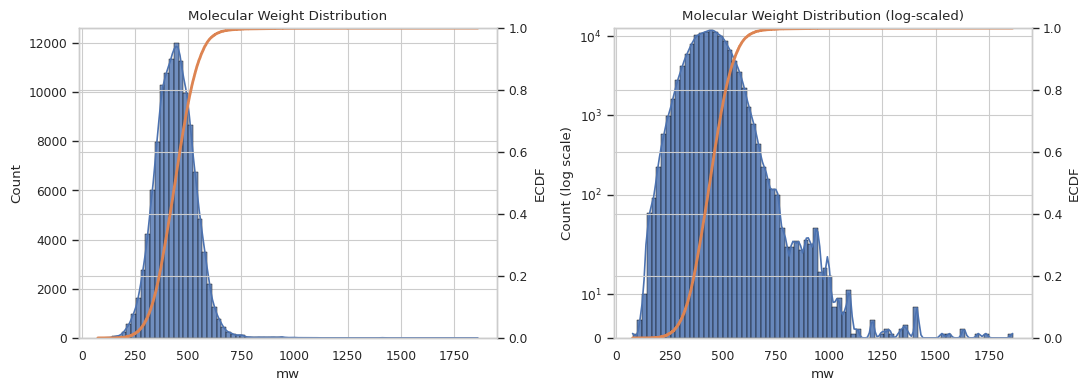

In [13]:
plot_dist_with_log(mws, col="mw", title="Molecular Weight Distribution", show_ecdf=True, 
                   kde=True,
                   context_overwrite="paper",
                   save_path=save_dir/"mw_distribution.png",)

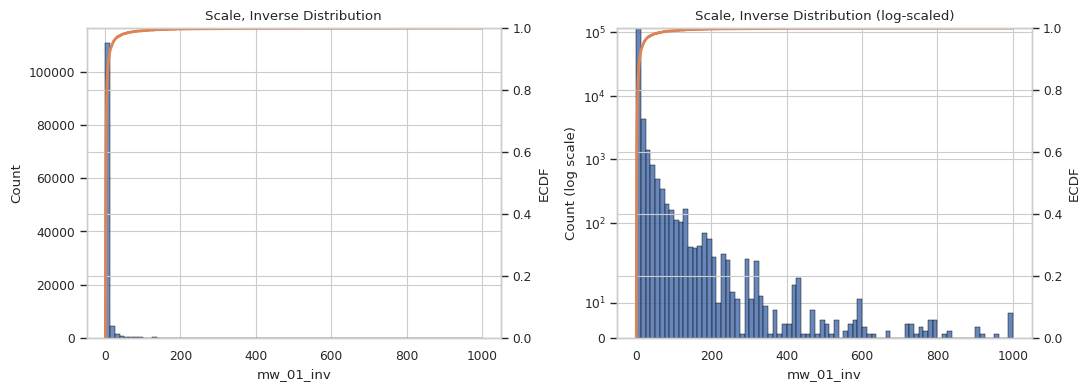

In [15]:
plot_dist_with_log(mws, col="mw_01_inv", title="Scale, Inverse Distribution", show_ecdf=True, context_overwrite="paper",
                   save_path=save_dir/"mw_01_inv_distribution.png",)

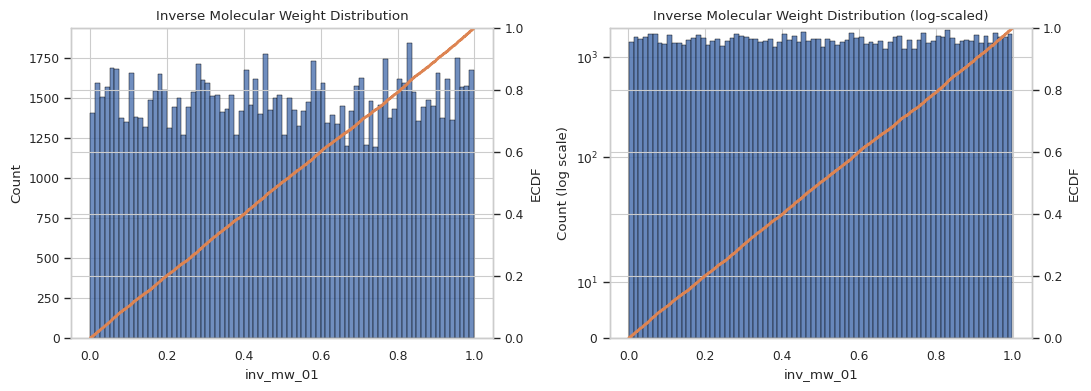

In [16]:
plot_dist_with_log(mws, col="inv_mw_01", title="Inverse Molecular Weight Distribution", show_ecdf=True, context_overwrite="paper",
save_path=save_dir/"inv_mw_01_distribution.png",)

Save as CSV

Add ident and smiles

In [9]:
# messy root path handling, but this is just a helper file and not a module, so it's fine for now
mws.to_csv(save_dir / "mws.csv", index=False)

Load to check

In [10]:
mws_loaded = pd.read_csv(save_dir / "mws.csv")
mws_loaded.head(2)

,smiles,ident,y_processed,activity_id,mw,mw_01,mw_01_inv,inv_mw,inv_mw_01
0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,0,5.148742,32335,370.456,0.226121,4.422403,0.002699,0.772132
1,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,17,6.000000,40693,386.455,0.289650,3.452437,0.002588,0.709651
